In [8]:
import torch
import matplotlib.pyplot as plt
from src.diffusion_mnist import Diffuser, CondDiffuser
from src.simple_unet import CondSimpleUnet
import pathlib

## 条件付き拡散モデルによる生成

## 学習済みモデルでの動作検証

In [9]:
def show_images_cond(images, labels, rows=2, cols=10):
    fig, ax = plt.subplots(rows, cols, figsize=(10, 2.5), sharey=True)
    i = 0
    for r in range(rows):
        for c in range(cols):
            ax[r, c].imshow(images[i], cmap='gray')
            ax[r, c].set_title(f"{labels[i]}", ha="center", fontsize=15)
            ax[r, c].axis('off')
            i += 1
    plt.tight_layout()
    plt.show()

In [10]:
num_labels = 10
model_dir = pathlib.Path(".") / "trained_models" 
# model_path = model_dir / "model_20260417.pth"
model_path = model_dir / "model_fashion_20260422.pth"

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [11]:
model_path = model_path
model_unet = CondSimpleUnet(num_labels=num_labels)
model_unet.load_state_dict(torch.load(model_path))
diffuser_mnist = CondDiffuser(model=model_unet,num_timesteps=500, beta_schedule_type="cosine", device=device)

In [12]:
# generate samples
# labels = torch.arange(0, 10).repeat(2)
# images = diffuser_mnist.ddpm_sampling(labels=labels)
# show_images_cond(images, labels)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:11<00:00,  4.25it/s]


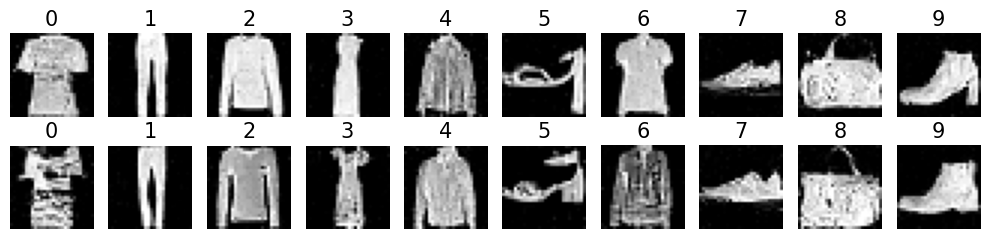

In [13]:
# generate samples
labels = torch.arange(0, 10).repeat(2)
images = diffuser_mnist.ddim_sampling(labels=labels, ddim_timestep=50, eta=0)
show_images_cond(images, labels)